# The Data Extractor
Our images are of size 125 x 125.U-Nets require spatial dimensions that can be cleanly halved and doubled multiple times (e.g. 128→64→32→16). If we feed a 125 x 125 tensor into a U-Net, it will hit fractional dimensions (125÷2=62.5) and PyTorch will throw a tensor mismatch error during the skip connections.  
The function **extract_n_samples()** pads the tensors to 128 x 128.

In [ ]:
import pyarrow.parquet as pq
import numpy as np
import torch
import torch.nn.functional as F

def parse_image_cell(cell):
    """
    Manually drills through the nested: 3 Channels -> 125 Rows -> 125 Pixels
    """
    parsed_channels = []
    for channel in cell:
        # channel is an array of 125 row objects.
        # force every single row to become a float array, then stack them.
        channel_2d = np.stack([np.array(row, dtype=np.float32) for row in channel])
        parsed_channels.append(channel_2d)

    # Stack the 3 finished channels into a (3, 125, 125) array
    return np.stack(parsed_channels)

def extract_n_samples(file_path, num_samples, batch_size=100):
    """
    Extracts N samples from a large Parquet file efficiently, applies physics
    preprocessing, and formats them for a U-Net.
    """
    print(f"Streaming {num_samples} samples from {file_path}...")
    parquet_file = pq.ParquetFile(file_path)

    hr_list = []
    lr_list = []
    samples_collected = 0

    # Iterate in chunks to prevent RAM overflow
    for batch in parquet_file.iter_batches(batch_size=batch_size):
        df_chunk = batch.to_pandas()

        for _, row in df_chunk.iterrows():
            if samples_collected >= num_samples:
                break

            # 1. Use the proven brute-force parser
            hr_cell = parse_image_cell(row['X_jets'])
            lr_cell = parse_image_cell(row['X_jets_LR'])

            hr_list.append(hr_cell)
            lr_list.append(lr_cell)
            samples_collected += 1

        if samples_collected >= num_samples:
            break

    print("Parsing complete. Converting to PyTorch Tensors...")
    hr_tensor = torch.tensor(np.stack(hr_list))
    lr_tensor = torch.tensor(np.stack(lr_list))

    # Crush negative electronic noise to pure zero
    hr_tensor = torch.clamp(hr_tensor, min=0.0)
    lr_tensor = torch.clamp(lr_tensor, min=0.0)

    # Log Transform: log(1 + x)
    hr_tensor = torch.log1p(hr_tensor)
    lr_tensor = torch.log1p(lr_tensor)

    # U-Net Padding for HR only (125x125 -> 128x128)
    pad_amounts = (1, 2, 1, 2)
    hr_tensor = F.pad(hr_tensor, pad_amounts, mode='constant', value=0.0)
    lr_tensor = F.pad(lr_tensor, (0, 0, 0, 0), mode='constant', value=0.0)

    print(f"Final High-Res Tensor Shape: {hr_tensor.shape}")
    print(f"Final Low-Res Tensor Shape:  {lr_tensor.shape}")

    return hr_tensor, lr_tensor

## Ploting the HR and LR data for Visual Verification

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_nth_data(hr_t, lr_t, sample_idx=0):
    print(f"\nPlotting Sample {sample_idx} to verify padding and alignment...")
    # Convert PyTorch (C, H, W) back to Matplotlib (H, W, C)
    hr_img = hr_t[sample_idx].cpu().numpy().transpose(1, 2, 0)
    lr_img = lr_t[sample_idx].cpu().numpy().transpose(1, 2, 0)

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
    channel_names = ['Tracks (Ch 0)', 'ECAL (Ch 1)', 'HCAL (Ch 2)']

    for c in range(3):
        # High-Res Row (Top)
        ax_hr = axes[0, c]
        vmax_val = np.nanmax(hr_img[:, :, c])
        if np.isnan(vmax_val) or vmax_val < 1e-4:
            vmax_val = 1.0  # Safe fallback if the image is empty
        im_hr = ax_hr.imshow(hr_img[:, :, c], cmap='jet', norm=LogNorm(vmin=1e-4, vmax=vmax_val + 1e-4))
        ax_hr.set_title(f"High-Res: {channel_names[c]}")
        fig.colorbar(im_hr, ax=ax_hr)
        ax_hr.axis('off')

        # Low-Res Row (Bottom)
        ax_lr = axes[1, c]
        im_lr = ax_lr.imshow(lr_img[:, :, c], cmap='jet', norm=LogNorm(vmin=1e-4, vmax=np.max(lr_img[:,:,c])+1e-4))
        ax_lr.set_title(f"Low-Res: {channel_names[c]}")
        fig.colorbar(im_lr, ax=ax_lr)
        ax_lr.axis('off')

    plt.tight_layout()
    plt.show()

# The Cosine Noise Scheduler


In [ ]:
import torch
import math

class CosineNoiseScheduler:
    def __init__(self, num_timesteps=1000, s=0.008):
        self.num_timesteps = num_timesteps

        # Cosine schedule formula
        steps = torch.arange(num_timesteps + 1, dtype=torch.float32)
        f_t = torch.cos(((steps / num_timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2

        # Save attributes
        self.alphas_cumprod = f_t / f_t[0]
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def to(self, device):
        """Move all schedule constants to the specified device (GPU)."""
        self.alphas_cumprod = self.alphas_cumprod.to(device)
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)
        return self

    def add_noise(self, original_hr, noise, t):
        device = original_hr.device
        batch_size = original_hr.shape[0]

        # If t is a single number, automatically duplicate it to match the batch size
        if t.numel() == 1:
            t = t.repeat(batch_size)

        # always safely reshape into [16, 1, 1, 1]
        sqrt_alpha = self.sqrt_alphas_cumprod.to(device)[t].view(batch_size, 1, 1, 1)
        sqrt_one_minus_alpha = self.sqrt_one_minus_alphas_cumprod.to(device)[t].view(batch_size, 1, 1, 1)

        return sqrt_alpha * original_hr + sqrt_one_minus_alpha * noise

# Sinusoidal Positional Embedding

In [4]:
import torch.nn as nn

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        # Converts the raw integer 'time' into a continuous sine/cosine vector
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# Log Transformation

In [ ]:
import torch

def log_transformation(hr_tensor, lr_tensor):
    """
    Translates the 'Log Transformation' box from the architecture diagram.
    Applies point-wise compression while protecting the physics sparsity.
    """
    # Crush negative hardware noise to absolute zero
    hr_clean = torch.clamp(hr_tensor, min=0.0)
    lr_clean = torch.clamp(lr_tensor, min=0.0)

    # The Log Transformation -> log(1 + x)
    # Compresses extreme energy spikes but keeps 0.0 as 0.0
    hr_transformed = torch.log1p(hr_clean)
    lr_transformed = torch.log1p(lr_clean)

    return hr_transformed, lr_transformed

# The Sparse Resnet Block

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# SPARSE RESNET BLOCK

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        # The first BatchNorm 
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        # The second BatchNorm 
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.act = nn.SiLU()

        # Skip connection
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, time_emb):
        # Pre-activation block
        h = self.conv1(self.act(self.bn1(x)))

        # Inject Time
        processed_time = self.mlp(time_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + processed_time

        # Second block
        h = self.conv2(self.act(self.bn2(h)))

        # Skip connection
        return h + self.residual_conv(x)

# The Attention Block

In [ ]:
import torchvision.models.swin_transformer as swin

# ATTENTION BLOCK (Official Torchvision Swin Transformer)

class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4, window_size=8, shift_size=0):
        super().__init__()

        # Torchvision Swin Block
        self.swin_block = swin.SwinTransformerBlock(
            dim=channels,
            num_heads=num_heads,
            window_size=[window_size, window_size],
            shift_size=[shift_size, shift_size],
            mlp_ratio=4.0,
            dropout=0.0,
            attention_dropout=0.0,
            stochastic_depth_prob=0.0
        )

    def forward(self, x):
        x_swin = x.permute(0, 2, 3, 1)

        # Apply the Swin Window Attention
        x_swin = self.swin_block(x_swin)

        # Convert back to (Batch, Channels, Height, Width) for the next U-Net layer
        out = x_swin.permute(0, 3, 1, 2)

        return out

# The U-Net

In [ ]:
# THE MAIN U-NET ARCHITECTURE

class PhysicsConditionalUNet(nn.Module):
    def __init__(self, image_channels=3, condition_channels=3, base_dim=64):
        super().__init__()

        # Time Embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_dim),
            nn.Linear(base_dim, base_dim * 4),
            nn.SiLU(),
            nn.Linear(base_dim * 4, base_dim * 4)
        )
        time_dim = base_dim * 4

        # ENCODER
        # Level 1 (128x128): HR (3) + Upscaled LR (3) = 6 channels
        self.inc = nn.Conv2d(image_channels + condition_channels, base_dim, 3, padding=1)
        self.res1 = ResBlock(base_dim, base_dim, time_dim)

        # Level 2 (64x64): Feature Map (64) + Native LR (3) = 67 channels!
        self.down1 = nn.Conv2d(base_dim, base_dim, 4, stride=2, padding=1)
        self.res2 = ResBlock(base_dim + condition_channels, base_dim * 2, time_dim)

        # Level 3 (32x32): Feature Map (128) + Downsampled LR (3) = 131 channels!
        self.down2 = nn.Conv2d(base_dim * 2, base_dim * 2, 4, stride=2, padding=1)
        self.res3 = ResBlock((base_dim * 2) + condition_channels, base_dim * 4, time_dim)

        # BOTTLENECK (16x16)
        self.down3 = nn.Conv2d(base_dim * 4, base_dim * 4, 4, stride=2, padding=1)
        self.attn1 = AttentionBlock(base_dim * 4)
        self.res_bot = ResBlock(base_dim * 4, base_dim * 4, time_dim)
        self.attn2 = AttentionBlock(base_dim * 4)

        # DECODER
        # Up 1 (32x32)
        self.up1 = nn.ConvTranspose2d(base_dim * 4, base_dim * 4, 4, stride=2, padding=1)
        self.up_res1 = ResBlock((base_dim * 4) + (base_dim * 4), base_dim * 2, time_dim) # + Skip connection

        # Up 2 (64x64)
        self.up2 = nn.ConvTranspose2d(base_dim * 2, base_dim * 2, 4, stride=2, padding=1)
        self.up_res2 = ResBlock((base_dim * 2) + (base_dim * 2), base_dim, time_dim)

        # Up 3 (128x128)
        self.up3 = nn.ConvTranspose2d(base_dim, base_dim, 4, stride=2, padding=1)
        self.up_res3 = ResBlock(base_dim + base_dim, base_dim, time_dim)

        # Final Noise Prediction
        self.final_conv = nn.Conv2d(base_dim, image_channels, 1)

    def forward(self, noisy_hr, lr_cond, timestep):
        # Determine the target size based on the actual input (64x64)
        target_size = noisy_hr.shape[-2:]

        # Process Time
        t = self.time_mlp(timestep)

        # ENCODER (Multi-Scale Injection)

        # Level 1 (64x64)
        lr_lvl1 = F.interpolate(lr_cond, size=target_size, mode='nearest')
        x = torch.cat([noisy_hr, lr_lvl1], dim=1)
        x1 = self.res1(self.inc(x), t)

        # Level 2 (32x32)
        x2 = self.down1(x1)
        lr_lvl2 = F.interpolate(lr_cond, size=x2.shape[-2:], mode='area')
        x2_injected = torch.cat([x2, lr_lvl2], dim=1)
        x2 = self.res2(x2_injected, t)

        # Level 3 (16x16)
        x3 = self.down2(x2)
        lr_lvl3 = F.interpolate(lr_cond, size=x3.shape[-2:], mode='area')
        x3_injected = torch.cat([x3, lr_lvl3], dim=1)
        x3 = self.res3(x3_injected, t)

        # Bottleneck
        x4 = self.down3(x3)
        x4 = self.attn1(x4)
        x4 = self.res_bot(x4, t)
        x4 = self.attn2(x4)

        # DECODER (With Skip Connections)

        u1 = self.up1(x4)
        u1 = torch.cat([u1, x3], dim=1) # Skip connection from Level 3
        u1 = self.up_res1(u1, t)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x2], dim=1) # Skip connection from Level 2
        u2 = self.up_res2(u2, t)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, x1], dim=1) # Skip connection from Level 1
        u3 = self.up_res3(u3, t)

        # Predict the Noise
        return self.final_conv(u3)

# Weighted L1 Loss with **Energy Conservation Constraint**

In [ ]:
class PhysicsGuidedLoss(nn.Module):
    def __init__(self, scheduler, hit_weight=15.0, energy_weight=0.1, pixel_weight=1.0):
        """
        hit_weight: Scaled dynamically. High-energy cores get massively penalized if missed.
        energy_weight: Global conservation of total shower energy.
        pixel_weight: NEW - Forces the physical energy to stay sharp and localized.
        """
        super().__init__()
        self.scheduler = scheduler
        self.hit_weight = hit_weight
        self.energy_weight = energy_weight
        self.pixel_weight = pixel_weight 

    def forward(self, predicted_noise, target_noise, x_0, x_t, t):
        # DYNAMIC ENERGY-PROPORTIONAL NOISE LOSS
        base_loss = F.l1_loss(predicted_noise, target_noise, reduction='none')

        #  multiply by x_0
        # If x_0 has a massive peak, the weight matrix forces the model to focus there.
        weight_matrix = 1.0 + (self.hit_weight * x_0)

        weighted_noise_loss = (base_loss * weight_matrix).mean()

        # EXTRACT PHYSICAL PREDICTIONS (x_0_hat)
        alphas_cumprod = self.scheduler.alphas_cumprod.to(x_t.device)
        alpha_bar_t = alphas_cumprod[t].view(-1, 1, 1, 1)

        x_0_hat = (x_t - torch.sqrt(1.0 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)

        real_energy_target = torch.expm1(torch.clamp(x_0, min=0.0, max=15.0))
        real_energy_predicted = torch.expm1(torch.clamp(x_0_hat, min=0.0, max=15.0))

        # LOCAL (PIXEL-WISE) PHYSICS CONSTRAINT
        pixel_energy_loss = F.l1_loss(real_energy_predicted, real_energy_target)

        # GLOBAL ENERGY CONSERVATION
        total_energy_target = real_energy_target.sum(dim=(2, 3))
        total_energy_predicted = real_energy_predicted.sum(dim=(2, 3))

        global_energy_loss = F.l1_loss(total_energy_predicted, total_energy_target)

        # TOTAL LOSS
        total_loss = weighted_noise_loss + (self.pixel_weight * pixel_energy_loss) + (self.energy_weight * global_energy_loss)

        return total_loss, weighted_noise_loss, global_energy_loss

# Prediction

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def predict_super_resolution(model, scheduler, lr_condition, device='cuda'):
    model.eval()
    lr_condition = lr_condition.to(device)
    batch_size = lr_condition.shape[0]
    target_channels = lr_condition.shape[1]

    # 128x128 Canvas
    x_t = torch.randn((batch_size, target_channels, 128, 128), device=device)

    alphas_cumprod = (scheduler.sqrt_alphas_cumprod ** 2).to(device)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

    betas = 1.0 - (alphas_cumprod / alphas_cumprod_prev)
    betas = torch.clamp(betas, min=1e-5, max=0.02)
    alphas = 1.0 - betas

    for i in tqdm(reversed(range(0, 1000)), total=1000, desc="Denoising Physics"):
        t_tensor = torch.full((batch_size,), i, device=device, dtype=torch.long)

        # Predict
        predicted_noise = model(x_t, lr_condition, t_tensor)

        # Added + 1e-8 to all denominators
        alpha_t = alphas[i]
        alpha_bar_t = alphas_cumprod[i]

        denom = torch.sqrt(1.0 - alpha_bar_t + 1e-8)
        coeff1 = 1.0 / torch.sqrt(alpha_t + 1e-8)
        coeff2 = (1.0 - alpha_t) / denom

        x_t = coeff1 * (x_t - coeff2 * predicted_noise)

        # Hard clamp to prevent drift
        x_t = torch.clamp(x_t, -10.0, 10.0)

        # Add stable noise
        if i > 0:
            noise = torch.randn_like(x_t)
            sigma = torch.sqrt(betas[i] + 1e-8)
            x_t = x_t + sigma * noise

    # Final clamp to remove negative background noise
    return torch.clamp(x_t, min=0.0)

## to check the progress of training

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

def check_progress(model, scheduler, lr_sample, hr_target, epoch, it):
    model.eval()
    device = hr_target.device

    with torch.no_grad():
        # Setup the batch and timestep
        batch_size = hr_target.shape[0]
        t = torch.full((batch_size,), 500, device=device, dtype=torch.long)

        # Add noise and predict
        actual_noise = torch.randn_like(hr_target)
        noisy_hr = scheduler.add_noise(hr_target, actual_noise, t)
        noise_pred = model(noisy_hr, lr_sample, t)

        # Setup the 4-panel plot
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))
        ch = 1 # Focusing on the ECAL channel

        # PLOTTING 
        def plot_panel(ax, tensor_data, title, use_lognorm=True):
            # Extract image and convert to numpy
            img = tensor_data[0, ch].cpu().numpy()

            if use_lognorm:
                # White background for physics
                vmax_val = np.nanmax(img)
                if np.isnan(vmax_val) or vmax_val <= 1e-4:
                    vmax_val = 1.0
                im = ax.imshow(img, cmap='jet', norm=LogNorm(vmin=1e-4, vmax=vmax_val + 1e-4))
            else:
                # Standard blue/red scale for Gaussian noise
                im = ax.imshow(img, cmap='jet')

            ax.set_title(title)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.axis('off')

        # Physics hits (White Background)
        plot_panel(axes[0], hr_target, "Ground Truth (HR)", use_lognorm=True)
        plot_panel(axes[1], lr_sample, "Input (LR Condition)", use_lognorm=True)

        # Noise hits (Standard Background)
        plot_panel(axes[2], noisy_hr, f"Noisy Canvas (t={t[0].item()})", use_lognorm=False)
        plot_panel(axes[3], noise_pred, "Predicted Noise", use_lognorm=False)

        plt.suptitle(f"Epoch {epoch} | Iteration {it}", fontsize=16)
        plt.tight_layout()

        plt.savefig(f"/kaggle/working/progress/progress_e{epoch}_it{it}.png")
        plt.show()
        plt.close()

    model.train()

# The Training Loop

In [ ]:
import torch
from tqdm import tqdm

def train_diffusion_model(model, dataloader, optimizer, noise_scheduler, loss_fn, folder_path, num_epochs=10, device='cuda'):
    """
    The master training loop for the Physics-Constrained Conditional U-Net.
    """
    model.to(device)
    model.train()

    print(f"Starting training for {num_epochs} epochs on {device}...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        # for progress bar
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (hr_real, lr_real) in enumerate(progress_bar):
            # Move data to device
            hr_real = hr_real.to(device)
            lr_real = lr_real.to(device)
            batch_size = hr_real.shape[0]

            # Call every 1000 iterations
            if batch_idx % 1000 == 0:
                check_progress(model, noise_scheduler, lr_real, hr_real, epoch+1, batch_idx)

            # 2. PHYSICS PREPROCESSING
            # Clamp negative hardware noise to 0.0, then apply log1p
            hr_clean = torch.clamp(hr_real, min=0.0)
            lr_clean = torch.clamp(lr_real, min=0.0)

            hr_log = torch.log1p(hr_clean)
            lr_log = torch.log1p(lr_clean)

            # 3. FORWARD DIFFUSION
            # Sample random timesteps [0, 999] for each image in the batch
            t = torch.randint(0, noise_scheduler.num_timesteps, (batch_size,), device=device).long()

            # Generate the true target noise
            target_noise = torch.randn_like(hr_log)

            # Fetch the cosine scheduler math constants
            sqrt_alpha_cumprod_t = noise_scheduler.sqrt_alphas_cumprod.to(device)[t].view(-1, 1, 1, 1)
            sqrt_one_minus_alpha_cumprod_t = noise_scheduler.sqrt_one_minus_alphas_cumprod.to(device)[t].view(-1, 1, 1, 1)

            # Create the corrupted noisy image (x_t)
            noisy_hr = sqrt_alpha_cumprod_t * hr_log + sqrt_one_minus_alpha_cumprod_t * target_noise

            # NEURAL NETWORK FORWARD PASS
            optimizer.zero_grad()

            # The U-Net tries to predict the target_noise
            predicted_noise = model(noisy_hr, lr_log, t)

            # PHYSICS-GUIDED LOSS & BACKPROPAGATION
            # Calculate  energy conservation loss
            total_loss, noise_loss, energy_loss = loss_fn(
                predicted_noise, target_noise, hr_log, noisy_hr, t
            )

            # Backpropagate the error
            total_loss.backward()

            # Prevent gradient explosions early in training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # TRACKING & LOGGING
            epoch_loss += total_loss.item()

            # Update the progress bar text in real-time
            progress_bar.set_postfix({
                "Total Loss": f"{total_loss.item():.4f}",
                "Energy Pen": f"{energy_loss.item():.4f}"
            })

        # Epoch summary
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch {epoch+1} Completed | Average Total Loss: {avg_loss:.4f}\n")

        if epoch%10 == 0:
            # Define the filename and full path
            model_filename = f"model_epoch_{epoch+1}.pth"
            save_full_path = os.path.join(folder_path, model_filename)
        
            # Save the weights
            torch.save(model.state_dict(), save_full_path)

        best_loss = float('inf')
        if total_loss < best_loss:
            best_loss = total_loss 
            best_path = os.path.join(folder_path, "best_model.pth")
            torch.save(model.state_dict(), best_path)
            print("New best model saved!")

        print(f"\nCheckpoint saved to: {save_full_path}")

    print("Training Complete! The model is ready for inference.")
    return model

# The Streaming Calorimeter Dataset
To prevent the crash , we will use pyarrow. It allows us to open a Parquet file and read it in "Row Groups" (small chunks of data) rather than loading the whole multi-gigabyte file into RAM.

In [ ]:
import torch
from torch.utils.data import IterableDataset
import pyarrow.parquet as pq
import numpy as np
import gc

class CalorimeterParquetDataset(IterableDataset):
    def __init__(self, file_list, batch_size=16):
        super().__init__()
        self.file_list = file_list
        self.batch_size = batch_size

        # Calculate the total rows once at the start
        self.total_rows = 0
        for f in file_list:
            meta = pq.read_metadata(f)
            self.total_rows += meta.num_rows

    def __len__(self):
        # Tell the DataLoader how many BATCHES to expect
        return self.total_rows // self.batch_size

    def __iter__(self):
        for file_path in self.file_list:
            parquet_file = pq.ParquetFile(file_path)

            for batch in parquet_file.iter_batches(batch_size=self.batch_size):
                # Grab the 'element' column
                col_data = batch.column(0)

                processed_images = []
                for x in col_data.to_pylist():
                    # x is a list of 12288 values
                    arr = np.array(x, dtype=np.float32)

                    if arr.size == 12288:
                        # Reshape to [Channels, H, W] -> [3, 64, 64]
                        img = arr.reshape(3, 64, 64)
                        processed_images.append(img)

                if not processed_images:
                    continue

                # HR is the 64x64 image from the file
                hr_tensor = torch.from_numpy(np.stack(processed_images)) # [B, 3, 64, 64]

                # LR is a 32x32 downsampled version created as the 'input'
                lr_tensor = torch.nn.functional.interpolate(
                    hr_tensor, size=(32, 32), mode='area'
                )

                yield hr_tensor, lr_tensor

                del processed_images, hr_tensor, lr_tensor
                gc.collect()

def get_dataloader(file_list, batch_size=16):
    dataset = CalorimeterParquetDataset(file_list, batch_size=batch_size)
    # batch_size=None because the dataset handles batching internally
    return torch.utils.data.DataLoader(dataset, batch_size=None, num_workers=2)

small test run before actual training

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader
import pyarrow.parquet as pq
import numpy as np
import math
from tqdm import tqdm
import torchvision.models.swin_transformer as swin

# Hardware Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")

# Initialize verified components
model = PhysicsConditionalUNet(image_channels=3, condition_channels=3, base_dim=64).to(device)
scheduler = CosineNoiseScheduler(num_timesteps=1000)
loss_fn = PhysicsGuidedLoss(scheduler, hit_weight=5.0, energy_weight=0.1)

# Setup Optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Setup Streaming Dataloader
my_files = ["/kaggle/input/datasets/bhagavatpratimdas/particle-energy/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet"] # Add paths
train_dataset = CalorimeterParquetDataset(my_files, batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=None, num_workers=0)

Training on: cuda


In [15]:
print("Testing data stream...")
test_iter = iter(train_loader)
for i in range(5):
    hr, lr = next(test_iter)
    print(f"Batch {i+1} loaded: HR {hr.shape}, LR {lr.shape}")
print("Stream stable! You can now start the training loop.")

Testing data stream...
Batch 1 loaded: HR torch.Size([16, 3, 64, 64]), LR torch.Size([16, 3, 32, 32])
Batch 2 loaded: HR torch.Size([16, 3, 64, 64]), LR torch.Size([16, 3, 32, 32])
Batch 3 loaded: HR torch.Size([16, 3, 64, 64]), LR torch.Size([16, 3, 32, 32])
Batch 4 loaded: HR torch.Size([16, 3, 64, 64]), LR torch.Size([16, 3, 32, 32])
Batch 5 loaded: HR torch.Size([16, 3, 64, 64]), LR torch.Size([16, 3, 32, 32])
Stream stable! You can now start the training loop.


In [ ]:
import os

save_dir = "/kaggle/working/weights"
os.makedirs(save_dir, exist_ok=True)
save_dir = "/kaggle/working/progress"
os.makedirs(save_dir, exist_ok=True)

print(f"Directory ready at: {save_dir}")

Directory ready at: /kaggle/working/progress


In [ ]:
if __name__ == "__main__":
    train_diffusion_model(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        noise_scheduler=scheduler,
        loss_fn=loss_fn,
        folder_path="/kaggle/working/weights",
        num_epochs=150,
        device=device
    )

    torch.save(model.state_dict(), "final_gsoc_model_64x64.pth")
    print("Training complete and model saved.")

# Load Trained Model

In [ ]:
def load_trained_model(checkpoint_path, device='cuda'):
    # Recreate the exact same architecture used during training
    model = PhysicsConditionalUNet(image_channels=3, condition_channels=3)

    # Load the weight dictionary
    state_dict = torch.load(checkpoint_path, map_location=device)

    # Load weights into the model
    model.load_state_dict(state_dict)

    # Move to device and set to evaluation mode
    model.to(device)
    model.eval()

    print(f" Model successfully loaded from: {checkpoint_path}")
    return model

my_path = "/kaggle/input/models/bhagavat3/sr-u-net-diffusion/pytorch/default/1/best_model.pth"
trained_model = load_trained_model(my_path, device='cuda')

✅ Model successfully loaded from: /kaggle/input/models/bhagavat3/sr-u-net-diffusion/pytorch/default/1/best_model.pth


## Verification of loaded model

In [ ]:
with torch.no_grad():
    hr, lr = next(iter(train_loader))

    # check if it can predict noise at t=0
    t_zero = torch.zeros(1).long().to(device)
    output = trained_model(hr.to(device), lr.to(device), t_zero)

    print(f"Output shape: {output.shape}")
    print(f"Max value in prediction: {output.max().item():.4f}")

Output shape: torch.Size([16, 3, 64, 64])
Max value in prediction: 54.4097


Streaming 5 samples from /kaggle/input/datasets/bhagavatpratimdas/particle-energy/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet...
Parsing complete. Converting to PyTorch Tensors...
Final High-Res Tensor Shape: torch.Size([5, 3, 128, 128])
Final Low-Res Tensor Shape:  torch.Size([5, 3, 64, 64])


Denoising Physics: 100%|██████████| 1000/1000 [00:14<00:00, 67.48it/s]



Plotting Sample 4 to verify padding and alignment...


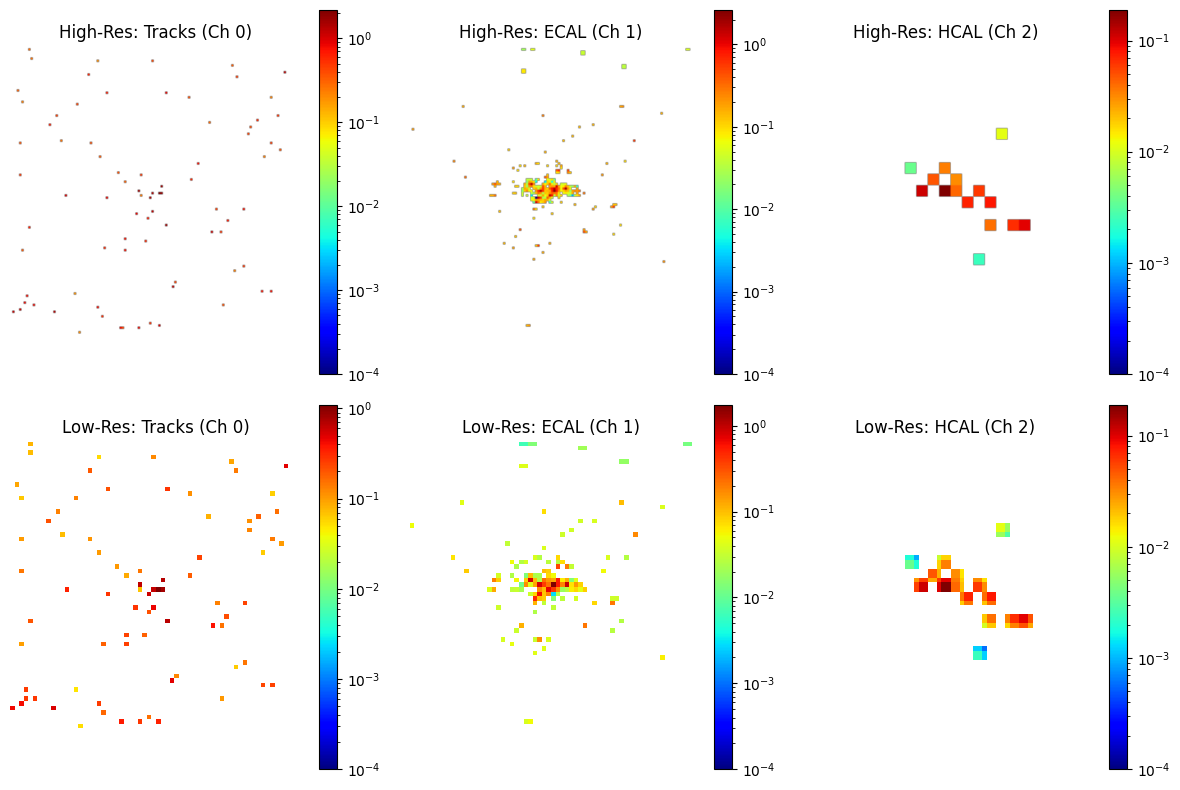


Plotting Sample 4 to verify padding and alignment...


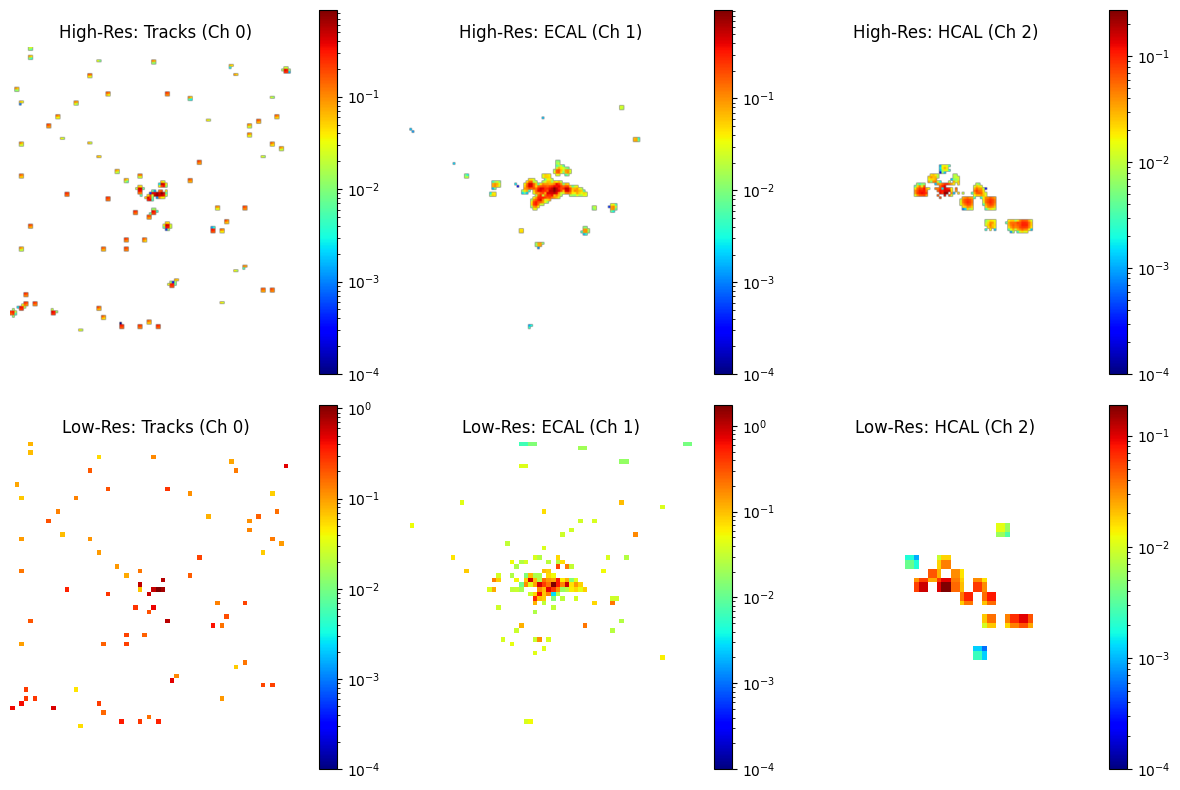

In [19]:
scheduler = CosineNoiseScheduler(num_timesteps=1000)
hr_gt, lr_cond = extract_n_samples('/kaggle/input/datasets/bhagavatpratimdas/particle-energy/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet', 5)
lr_cond_log = torch.log1p(lr_cond)
hr_pred = predict_super_resolution(trained_model, scheduler, lr_cond_log, device='cuda')
plot_nth_data(hr_gt, lr_cond, 4)
hr_pred = torch.clamp(hr_pred, max=1e5)
plot_nth_data(hr_pred, lr_cond, 4)

# Testing the Energy Conservation of the Model Prediction

Evaluating Energy Conservation over 50 batches...


Processing Samples:   0%|          | 0/50 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

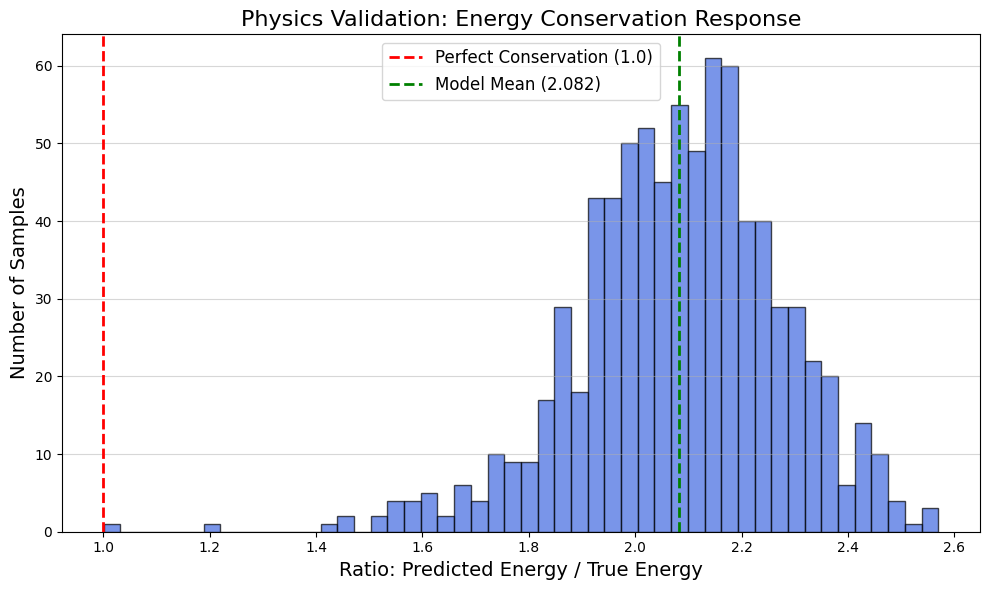


=== FINAL PHYSICS STATS ===
Mean Energy Ratio: 2.0815 (Ideal is exactly 1.0000)
Standard Deviation: 0.1947 (Lower means more consistent predictions)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

@torch.no_grad()
def evaluate_energy_conservation(model, scheduler, dataloader, device='cuda', num_batches=5):
    """
    Evaluates how well the model conserves physical energy by comparing
    the total pixel sum of the Ground Truth HR to the Predicted HR.
    """
    model.eval()
    model.to(device)

    energy_ratios = []

    print(f"Evaluating Energy Conservation over {num_batches} batches...")

    # Create an iterator from dataloader
    data_iter = iter(dataloader)

    for _ in tqdm(range(num_batches), desc="Processing Samples", position=0, leave=True):
        try:
            hr_gt, lr_cond = next(data_iter)
        except StopIteration:
            break # Reached the end of the dataset

        hr_gt = hr_gt.to(device)
        lr_cond = lr_cond.to(device)

        # Prepare the condition
        lr_cond_log = torch.log1p(lr_cond)

        # Generate the Super-Resolved Prediction
        hr_pred = predict_super_resolution(model, scheduler, lr_cond_log, device=device)

        # Calculate Total Energy per sample
        true_energy = hr_gt.sum(dim=[1, 2, 3]).cpu().numpy()
        pred_energy = hr_pred.sum(dim=[1, 2, 3]).cpu().numpy()

        # Calculate the ratio (Prediction / Ground Truth)
        for te, pe in zip(true_energy, pred_energy):
            if te > 0:
                energy_ratios.append(pe / te)

    # PLOTTING THE HISTOGRAM
    plt.figure(figsize=(10, 6))

    # Create the histogram
    plt.hist(energy_ratios, bins=50, color='royalblue', alpha=0.7, edgecolor='black')

    # Add benchmark lines
    plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='Perfect Conservation (1.0)')

    mean_ratio = np.mean(energy_ratios)
    std_ratio = np.std(energy_ratios)
    plt.axvline(mean_ratio, color='green', linestyle='dashed', linewidth=2, label=f'Model Mean ({mean_ratio:.3f})')

    plt.title("Physics Validation: Energy Conservation Response", fontsize=16)
    plt.xlabel("Ratio: Predicted Energy / True Energy", fontsize=14)
    plt.ylabel("Number of Samples", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.5)

    plt.tight_layout()
    plt.savefig("final_energy_conservation_histogram.png")
    plt.show()

    print(f"\nFINAL PHYSICS STATS")
    print(f"Mean Energy Ratio: {mean_ratio:.4f} (Ideal is exactly 1.0000)")
    print(f"Standard Deviation: {std_ratio:.4f} (Lower means more consistent predictions)")

    return energy_ratios

ratios = evaluate_energy_conservation(trained_model, scheduler, train_loader, device='cuda', num_batches=50)

# 10 step Denoising Preogression

In [ ]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

@torch.no_grad()
def plot_diffusion_process(model, scheduler, lr_condition, device='cuda'):
    model.eval()
    lr_condition = lr_condition.to(device)
    # Ensure we are looking at a single sample
    if lr_condition.dim() == 3: 
        lr_condition = lr_condition.unsqueeze(0)
    
    batch_size = 1
    # Start with pure Gaussian noise
    x_t = torch.randn((batch_size, 3, 128, 128), device=device)
    
    # Setup scheduler constants
    alphas_cumprod = (scheduler.sqrt_alphas_cumprod ** 2).to(device)
    alphas_cumprod_prev = torch.nn.functional.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    betas = torch.clamp(1.0 - (alphas_cumprod / alphas_cumprod_prev), min=1e-5, max=0.02)
    alphas = 1.0 - betas

    # Intervals for plotting (10 steps)
    plot_steps = torch.linspace(999, 0, 10).long().tolist()
    fig, axes = plt.subplots(1, 10, figsize=(25, 3))
    plot_idx = 0

    lr_log = torch.log1p(lr_condition)

    for i in reversed(range(0, 1000)):
        t_tensor = torch.full((batch_size,), i, device=device, dtype=torch.long)
        pred_noise = model(x_t, lr_log, t_tensor)

        # Denoising Step
        alpha_t = alphas[i]
        alpha_bar_t = alphas_cumprod[i]
        denom = torch.sqrt(1.0 - alpha_bar_t + 1e-8)
        coeff1 = 1.0 / torch.sqrt(alpha_t + 1e-8)
        coeff2 = (1.0 - alpha_t) / denom
        x_t = coeff1 * (x_t - coeff2 * pred_noise)
        
        if i > 0:
            x_t = x_t + torch.sqrt(betas[i] + 1e-8) * torch.randn_like(x_t)
        
        x_t = torch.clamp(x_t, -10.0, 10.0)

        # Capture progress
        if i in plot_steps:
            img_plot = torch.clamp(x_t[0, 1], min=0).cpu().numpy() # Channel 1 (ECAL)
            axes[plot_idx].imshow(img_plot, cmap='jet', norm=LogNorm(vmin=1e-3, vmax=img_plot.max()+1e-2))
            axes[plot_idx].set_title(f"T={i}")
            axes[plot_idx].axis('off')
            plot_idx += 1

    plt.suptitle("Diffusion Denoising Process (ECAL Channel)", fontsize=16)
    plt.show()

# Plot LR, HR_Gt, HR_Pred

In [ ]:
@torch.no_grad()
def plot_sr_comparison(model, scheduler, hr_gt, lr_input, device='cuda'):
    model.eval()
    
    # Generate Prediction
    lr_log = torch.log1p(lr_input.to(device))
    if lr_log.dim() == 3: lr_log = lr_log.unsqueeze(0)
    
    hr_pred = predict_super_resolution(model, scheduler, lr_log, device=device)
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = ['Low-Res Input (32x32)', 'Ground Truth HR (125x125)', 'Predicted HR (128x128)']
    
    # Data list for easier iteration
    images = [lr_input[0, 1].cpu(), hr_gt[0, 1].cpu(), hr_pred[0, 1].cpu()]
    
    for i, img in enumerate(images):
        # Using LogNorm
        vmax = img.max() + 1e-4
        im = axes[i].imshow(img, cmap='jet', norm=LogNorm(vmin=1e-4, vmax=vmax))
        axes[i].set_title(titles[i])
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Denoising Physics:   0%|          | 0/1000 [00:00<?, ?it/s]

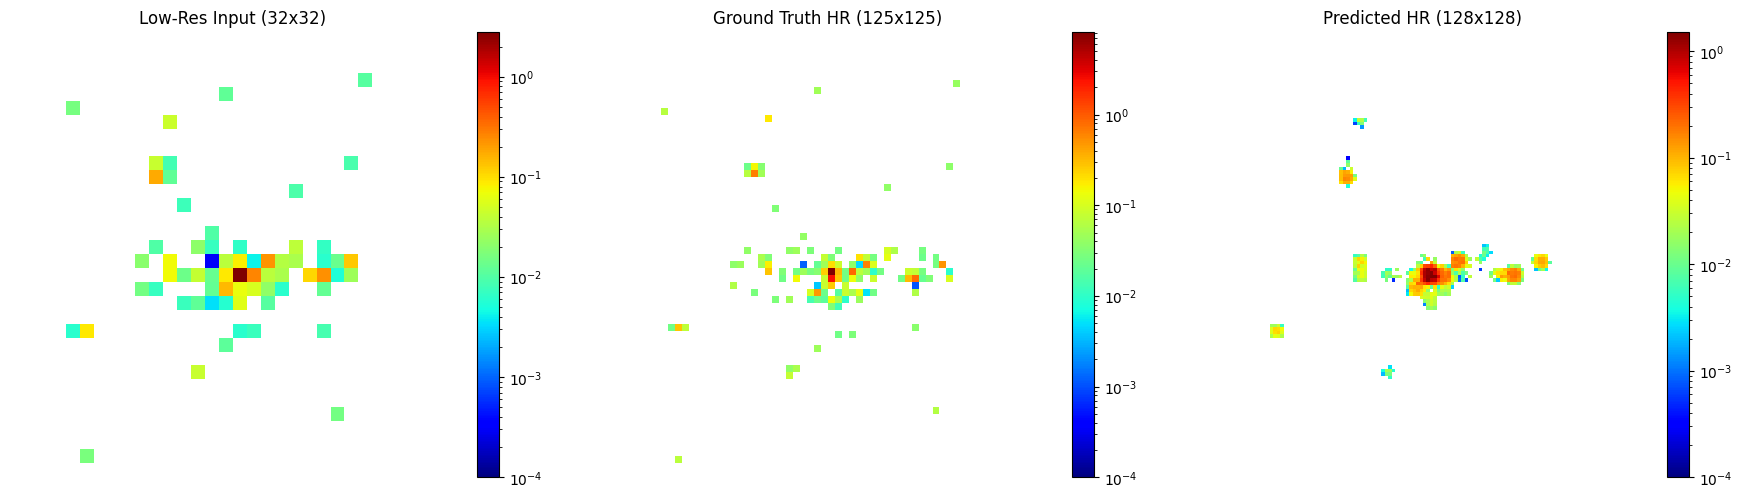

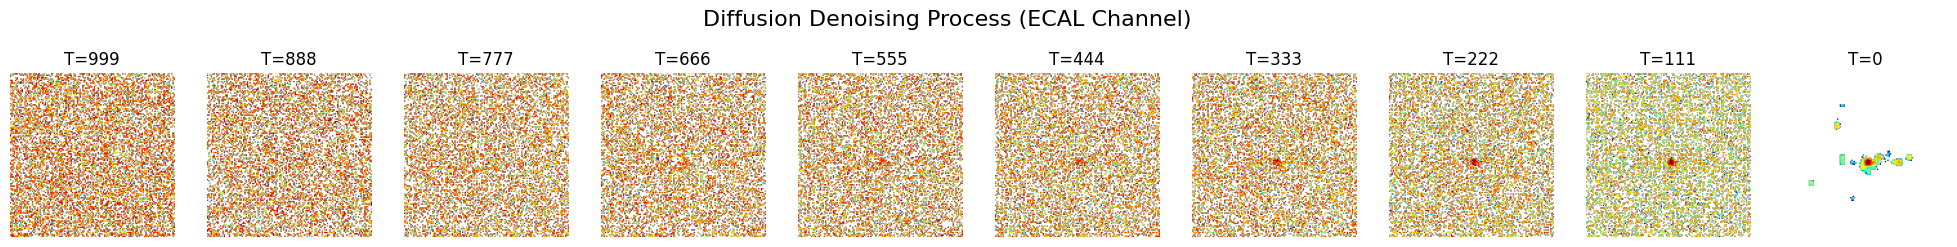

In [ ]:
# Grab a random sample
hr_sample, lr_sample = next(iter(train_loader))

# See the comparison
plot_sr_comparison(trained_model, scheduler, hr_sample, lr_sample)

# See the 10-step process
plot_diffusion_process(trained_model, scheduler, lr_sample[0])